In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target   # 0 = Malignant, 1 = Benign

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothnes

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [3]:
print("Missing values per column:\n", df.isnull().sum().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Drop duplicates if any exist
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

Missing values per column:
 0

Number of duplicate rows: 0

Shape after removing duplicates: (569, 31)


In [4]:
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

split_ratios = {'80:20': 0.2, '70:30': 0.3, '90:10': 0.1}
split_results = {}

for name, test_size in split_ratios.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )
    knn_temp = KNeighborsClassifier(n_neighbors=5)
    knn_temp.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test))
    split_results[name] = acc
    print(f"Split {name} -> Test samples: {X_test.shape[0]}, Accuracy: {acc:.4f}")

Split 80:20 -> Test samples: 114, Accuracy: 0.9474
Split 70:30 -> Test samples: 171, Accuracy: 0.9591
Split 90:10 -> Test samples: 57, Accuracy: 0.9298


In [6]:
# Finalize the split we'll use for the rest of the notebook: 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [7]:
n = X_train.shape[0]
k_heuristic = int(np.sqrt(n))

# Keep K odd to avoid ties in binary classification
if k_heuristic % 2 == 0:
    k_heuristic += 1

print(f"Number of training samples: {n}")
print(f"Heuristic K (sqrt(n), adjusted to odd): {k_heuristic}")

Number of training samples: 455
Heuristic K (sqrt(n), adjusted to odd): 21


In [8]:
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)
accuracies = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)
    print(f"K={k} -> Accuracy: {acc:.4f}")

K=16 -> Accuracy: 0.9561
K=17 -> Accuracy: 0.9474
K=18 -> Accuracy: 0.9561
K=19 -> Accuracy: 0.9474
K=20 -> Accuracy: 0.9474
K=21 -> Accuracy: 0.9474
K=22 -> Accuracy: 0.9474
K=23 -> Accuracy: 0.9474
K=24 -> Accuracy: 0.9474
K=25 -> Accuracy: 0.9474
K=26 -> Accuracy: 0.9474


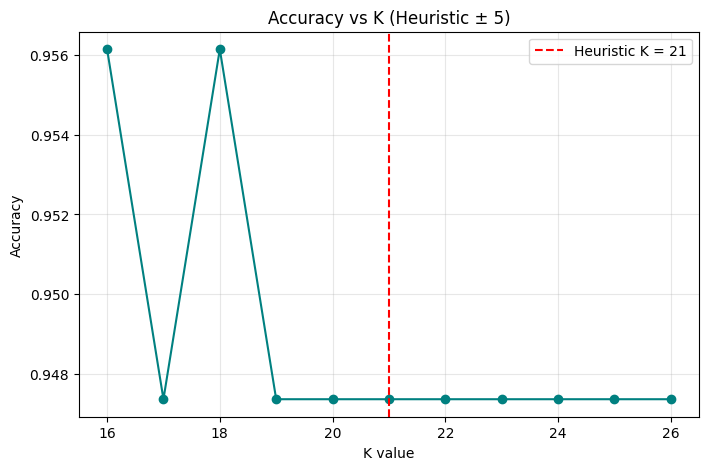

Best performing K in this range: 16 with accuracy 0.9561


In [9]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range), accuracies, marker='o', color='teal')
plt.axvline(x=k_heuristic, color='red', linestyle='--', label=f'Heuristic K = {k_heuristic}')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K (Heuristic ± 5)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(k_range)[np.argmax(accuracies)]
print(f"Best performing K in this range: {best_k} with accuracy {max(accuracies):.4f}")

Looking at the accuracy vs K plot, we pick the K value that gives the 
highest test accuracy in this range. This becomes our optimal K based on 
the heuristic + nearby search approach.

In [10]:
for metric in ['euclidean', 'manhattan']:
    knn_metric = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn_metric.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn_metric.predict(X_test))
    print(f"Distance metric: {metric} -> Accuracy: {acc:.4f}")

Distance metric: euclidean -> Accuracy: 0.9561
Distance metric: manhattan -> Accuracy: 0.9561


To visualize decision boundaries, we need exactly 2 features (since we can 
only plot in 2D). We'll use PCA to reduce our 30 features down to the 2 
most informative principal components, then plot how the decision boundary 
changes as K increases.

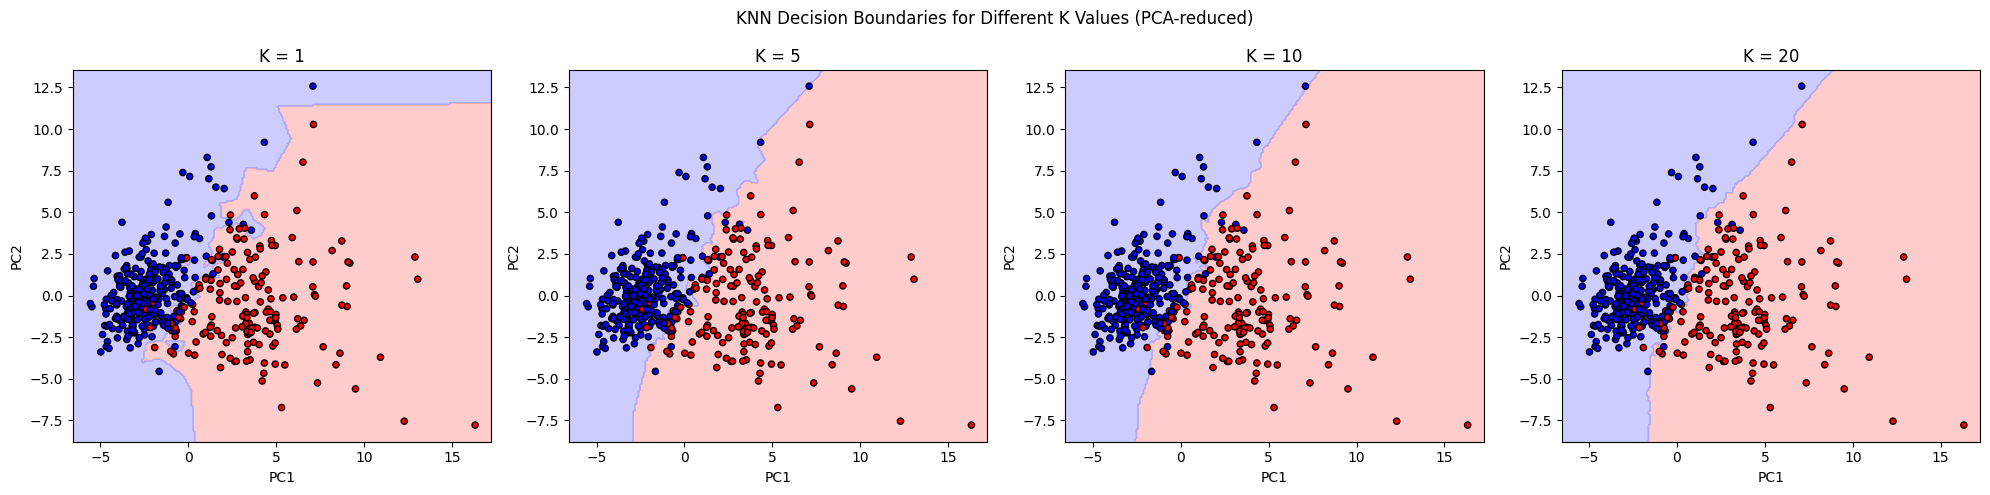

In [11]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

k_values = [1, 5, 10, 20]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, k in enumerate(k_values):
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train_pca)

    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                          np.arange(y_min, y_max, 0.1))

    Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    axes[idx].contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    axes[idx].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, 
                       edgecolor='k', cmap=ListedColormap(['red', 'blue']), s=20)
    axes[idx].set_title(f"K = {k}")
    axes[idx].set_xlabel("PC1")
    axes[idx].set_ylabel("PC2")

plt.suptitle("KNN Decision Boundaries for Different K Values (PCA-reduced)")
plt.tight_layout()
plt.show()

K-Fold Cross-Validation

In [12]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_scaled, y, cv=5, scoring='accuracy')
    cv_results[k] = scores.mean()
    print(f"K={k} -> Mean CV Accuracy (5-fold): {scores.mean():.4f}, Std: {scores.std():.4f}")

best_k_cv = max(cv_results, key=cv_results.get)
print(f"\nBest K based on cross-validation: {best_k_cv} with mean accuracy {cv_results[best_k_cv]:.4f}")

K=16 -> Mean CV Accuracy (5-fold): 0.9649, Std: 0.0147
K=17 -> Mean CV Accuracy (5-fold): 0.9578, Std: 0.0151
K=18 -> Mean CV Accuracy (5-fold): 0.9578, Std: 0.0170
K=19 -> Mean CV Accuracy (5-fold): 0.9543, Std: 0.0140
K=20 -> Mean CV Accuracy (5-fold): 0.9526, Std: 0.0196
K=21 -> Mean CV Accuracy (5-fold): 0.9526, Std: 0.0162
K=22 -> Mean CV Accuracy (5-fold): 0.9543, Std: 0.0178
K=23 -> Mean CV Accuracy (5-fold): 0.9543, Std: 0.0178
K=24 -> Mean CV Accuracy (5-fold): 0.9561, Std: 0.0156
K=25 -> Mean CV Accuracy (5-fold): 0.9543, Std: 0.0178
K=26 -> Mean CV Accuracy (5-fold): 0.9526, Std: 0.0196

Best K based on cross-validation: 16 with mean accuracy 0.9649


In [13]:
final_k = best_k_cv  # combining heuristic + validation results
print(f"Final chosen K for the model: {final_k}")

final_knn = KNeighborsClassifier(n_neighbors=final_k)
final_knn.fit(X_train, y_train)
y_pred = final_knn.predict(X_test)
y_pred_proba = final_knn.predict_proba(X_test)[:, 1]

Final chosen K for the model: 16


In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, roc_auc_score)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nFull Classification Report:\n", classification_report(y_test, y_pred))

Accuracy  : 0.9561
Precision : 0.9583
Recall    : 0.9718
F1 Score  : 0.9650

Full Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



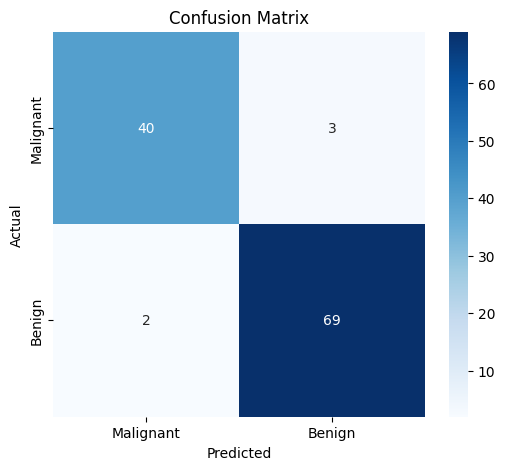

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Malignant', 'Benign'], 
            yticklabels=['Malignant', 'Benign'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve and AUC Score

The ROC (Receiver Operating Characteristic) curve plots the True Positive 
Rate against the False Positive Rate at different classification 
thresholds. The AUC (Area Under Curve) summarizes this into a single 
number — closer to 1 means the model separates the two classes almost 
perfectly, while 0.5 means it performs no better than random guessing.

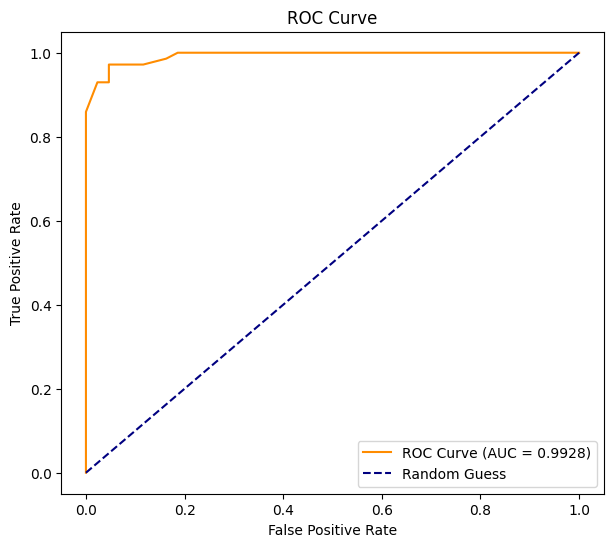

AUC Score: 0.9928


In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"AUC Score: {auc_score:.4f}")